In [30]:
import os
from brainnetwork import load_data, preprocess_data, preprocess_spike_data
import numpy as np
import umap
import matplotlib.pyplot as plt
import seaborn as sns

add_resting_state = True  # Whether to add resting state data for comparison

base_dir = "/beegfs_hdd/data/nfs_share/users/guiyun/nishome/Micedata/"
data_path = base_dir + 'M77_1031' # 'M77_1031'

In [31]:
neuron_data, neuron_pos, start_edges, stimulus_data = load_data(data_path)
segments_spi, labels_spi, neuron_pos_spi = preprocess_spike_data(
        neuron_data,
        neuron_pos,
        start_edges,
        stimulus_data,
        extract_rr=1
    )


原始神经数据形状: (7681, 35896)
使用快速RR筛选算法 (按类分别筛选取并集)...
三类并集后共筛选出 723 个唯一 RR 神经元


In [32]:
import numpy as np

def process_neural_data_ordered(segments, labels, add_resting=True, time_dim=2):
    """
    保持 Trial 时间顺序的数据处理函数
    用于 Drift / Adaptation / Trajectory 分析
    """
    
    n_trials = segments.shape[0]
    
    # ---------------------------------------------------------
    # 1. 定义时间窗口
    # ---------------------------------------------------------
    stim_window = slice(10, 15) 
    rest_window = slice(5, 10)
    
    # ---------------------------------------------------------
    # 2. 计算基础数据
    # ---------------------------------------------------------
    if time_dim == 2: # (Trial, Neuron, Time)
        X_stim_all = np.mean(segments[:, :, stim_window], axis=2)
        X_rest_all = np.mean(segments[:, :, rest_window], axis=2)
    else:             # (Trial, Time, Neuron)
        X_stim_all = np.mean(segments[:, stim_window, :], axis=1)
        X_rest_all = np.mean(segments[:, rest_window, :], axis=1)

    # ---------------------------------------------------------
    # 3. 平衡数据 (关键修正：保持时间顺序)
    # ---------------------------------------------------------
    unique_labels = np.unique(labels)
    # 计算最小数量
    min_count = min(np.sum(labels == l) for l in unique_labels)
    print(f"平衡目标数量 (截取前 {min_count} 个 Trial): {min_count}")

    X_list = []
    y_list = []
    
    # 这里的关键是：我们不再随机抽，而是按原始索引顺序取
    
    for label in unique_labels:
        # 1. 找到该 label 所有 trial 的原始索引 (本身就是有序的)
        label_indices = np.where(labels == label)[0]
        
        # 2. [关键!] 截取前 min_count 个
        # 这样保留了该条件下 Trial 1 -> Trial N 的演变过程
        selected_indices = label_indices[:min_count]
        
        X_list.append(X_stim_all[selected_indices])
        y_list.extend([label] * min_count)
        
    # ---------------------------------------------------------
    # 4. 添加静息态 (Resting) - 推荐策略
    # ---------------------------------------------------------
    if add_resting:
        # 策略 A: 如果你想看 "随着实验进行，静息态是否也在漂移"
        # 那么我们应该取 *所有* 被选中的 Stimulus Trial 对应的静息态
        # 但这样会导致静息态数量 = Stimulus 总数，造成不平衡。
        
        # 策略 B (推荐): 为了保持类别平衡，我们取"全局"的前 min_count 个静息态
        # 或者取每个 Condition 对应的前 min_count/3 个静息态。
        
        # 为了简单且保持时间线，我们直接取整个实验的最开始 min_count 个试次的静息态
        # 这样代表了实验初期的基线状态
        rest_indices = np.arange(min_count) 
        
        # 或者，如果你希望 Resting 也是混合了整个实验过程的（为了公平对比 Drift）
        # 我们可以每隔几个取一个，保持时间分布均匀
        # rest_indices = np.linspace(0, n_trials-1, min_count, dtype=int)
        
        X_list.append(X_rest_all[rest_indices])
        y_list.extend([0] * min_count)
        
        print(f"已添加静息态 (取实验中索引为 {rest_indices[0]} 到 {rest_indices[-1]} 的试次)")

    # ---------------------------------------------------------
    # 5. 合并
    # ---------------------------------------------------------
    X_final = np.vstack(X_list)
    y_final = np.array(y_list)
    
    # 语义映射
    label_map = {1: 'Divergent', 2: 'Convergent', 3: 'Random'}
    if add_resting:
        label_map[0] = 'Resting'

    print(f"最终数据形状: {X_final.shape}")
    
    return X_final, y_final, label_map

# ==========================================
# 运行处理
# ==========================================
X_ordered, y_ordered, label_map = process_neural_data_ordered(
    segments_spi, 
    labels_spi, 
    add_resting=add_resting_state,
    time_dim=2 
)

# ==========================================
# 重要提示：后续分析如何使用这个数据
# ==========================================
# 现在 X_ordered 是分块有序的，结构如下：
# [ Div_Trial_1, Div_Trial_2, ... Div_Trial_N, 
#   Con_Trial_1, Con_Trial_2, ... Con_Trial_N,
#   Ran_Trial_1, Ran_Trial_2, ... Ran_Trial_N ]
#
# 所以在做 Drift 分析时，你不能直接对整个 X_ordered 画线。
# 你需要先按 label 切分，然后单独画每个 block 的线。

平衡目标数量 (截取前 43 个 Trial): 43
已添加静息态 (取实验中索引为 0 到 42 的试次)
最终数据形状: (172, 723)


Starting Neuron Dropout Analysis...
Fraction 0.01: Rand=0.63, Best=0.62, Weak=0.39
Fraction 0.05: Rand=0.84, Best=0.82, Weak=0.41
Fraction 0.1: Rand=0.88, Best=0.89, Weak=0.52
Fraction 0.2: Rand=0.91, Best=0.91, Weak=0.63
Fraction 0.4: Rand=0.97, Best=0.94, Weak=0.83
Fraction 0.6: Rand=0.96, Best=0.95, Weak=0.85
Fraction 0.8: Rand=0.98, Best=0.97, Weak=0.93
Fraction 1.0: Rand=0.98, Best=0.98, Weak=0.98


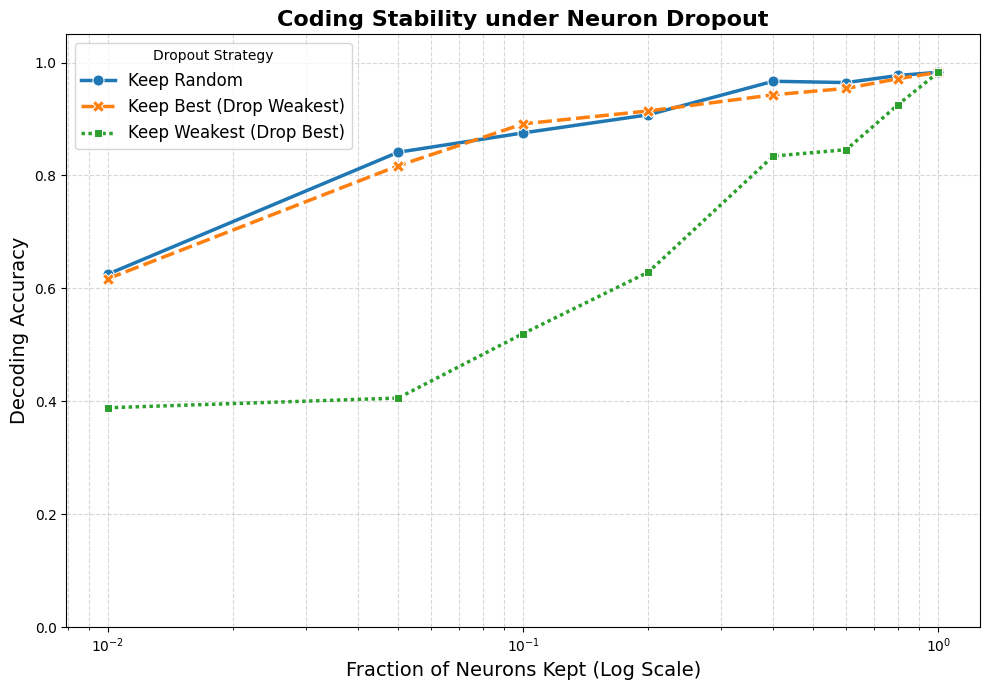

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedShuffleSplit, cross_val_score
from sklearn.neighbors import NearestCentroid
from sklearn.feature_selection import f_classif
from sklearn.preprocessing import StandardScaler

def run_neuron_dropout_analysis(X, labels, label_map):
    """
    执行神经元 Dropout 分析，对比编码稳定性
    策略:
    1. Drop Random: 随机移除
    2. Drop Best: 移除选择性最强的 (斩首)
    3. Drop Weakest: 移除选择性最弱的 (去弱)
    """
    print("Starting Neuron Dropout Analysis...")
    
    # 只需要二分类或多分类任务
    # 为了简化，我们测试 "各条件的可辨别性" (Rest vs Rand vs Div vs Conv)
    # 或者专注于 Coherent 内部的区分 (Div vs Conv) 和 Random 的区分 (Rand vs Rest)
    # 这里我们做全局解码 (Global Decoding Accuracy)
    
    y = labels.copy()
    
    # 1. 计算每个神经元的重要性 (Feature Importance)
    # 使用 ANOVA F-value 衡量每个神经元对类别的区分能力
    f_scores, _ = f_classif(X, y)
    # 排序索引: 从小到大 (Weakest -> Strongest)
    sorted_indices = np.argsort(f_scores)
    
    # 定义保留比例
    fractions = [0.01, 0.05, 0.1, 0.2, 0.4, 0.6, 0.8, 1.0]
    n_total = X.shape[1]
    
    # 存储结果
    results = {'Fraction': [], 'Accuracy': [], 'Strategy': []}
    
    clf = NearestCentroid() # 简单快速的分类器，适合高维
    cv = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=42)
    
    for frac in fractions:
        n_keep = int(n_total * frac)
        if n_keep < 2: n_keep = 2
        
        # --- Strategy A: Keep Random (Random Dropout) ---
        # 重复几次取平均
        accs_rand = []
        for i in range(5): 
            rand_indices = np.random.choice(n_total, n_keep, replace=False)
            X_sub = X[:, rand_indices]
            scores = cross_val_score(clf, X_sub, y, cv=cv)
            accs_rand.append(scores.mean())
        
        results['Fraction'].append(frac)
        results['Accuracy'].append(np.mean(accs_rand))
        results['Strategy'].append('Keep Random')
        
        # --- Strategy B: Keep Best (Drop Weakest) ---
        # 保留 F-score 最高的 n_keep 个 (即 sorted_indices 的最后 n_keep 个)
        best_indices = sorted_indices[-n_keep:]
        X_sub_best = X[:, best_indices]
        scores_best = cross_val_score(clf, X_sub_best, y, cv=cv)
        
        results['Fraction'].append(frac)
        results['Accuracy'].append(scores_best.mean())
        results['Strategy'].append('Keep Best (Drop Weakest)')
        
        # --- Strategy C: Keep Weakest (Drop Best) ---
        # 保留 F-score 最低的 n_keep 个 (即 sorted_indices 的前 n_keep 个)
        weak_indices = sorted_indices[:n_keep]
        X_sub_weak = X[:, weak_indices]
        scores_weak = cross_val_score(clf, X_sub_weak, y, cv=cv)
        
        results['Fraction'].append(frac)
        results['Accuracy'].append(scores_weak.mean())
        results['Strategy'].append('Keep Weakest (Drop Best)')
        
        print(f"Fraction {frac}: Rand={np.mean(accs_rand):.2f}, Best={scores_best.mean():.2f}, Weak={scores_weak.mean():.2f}")

    # --- 绘图 ---
    import pandas as pd
    df_res = pd.DataFrame(results)
    
    plt.figure(figsize=(10, 7))
    sns.lineplot(data=df_res, x='Fraction', y='Accuracy', hue='Strategy', 
                 style='Strategy', markers=True, linewidth=2.5, markersize=8)
    
    plt.xscale('log') # 对数坐标看低比例区
    plt.title('Coding Stability under Neuron Dropout', fontsize=16, fontweight='bold')
    plt.xlabel('Fraction of Neurons Kept (Log Scale)', fontsize=14)
    plt.ylabel('Decoding Accuracy', fontsize=14)
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.ylim(0, 1.05)
    plt.legend(title='Dropout Strategy', fontsize=12)
    plt.tight_layout()
    plt.show()

# 运行代码
run_neuron_dropout_analysis(X_ordered, y_ordered, label_map)

Running Robustness Analysis (Random Neuron Dropout)...


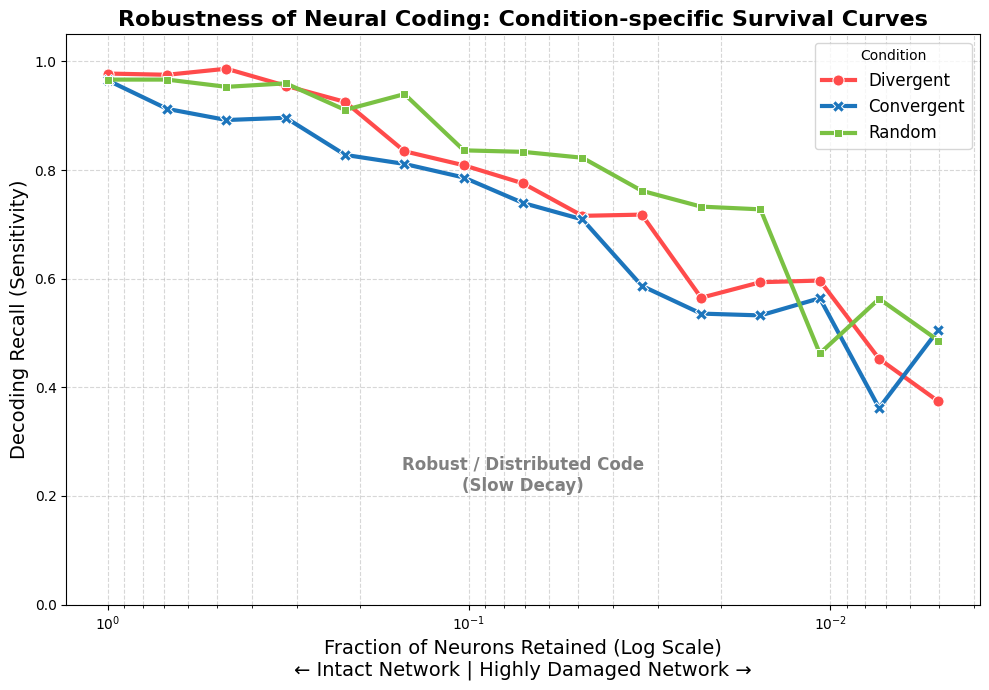

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedShuffleSplit, cross_val_score
from sklearn.neighbors import NearestCentroid
from sklearn.metrics import recall_score, confusion_matrix
from sklearn.preprocessing import StandardScaler

def plot_condition_robustness(X, labels, label_map):
    """
    对比不同条件在神经元随机切除下的解码鲁棒性 (Survival Curve)
    """
    print("Running Robustness Analysis (Random Neuron Dropout)...")
    
    # 设定保留比例 (从 100% 降到 0.5%) - 使用对数分布在低比例区采样更密
    fractions = np.logspace(0, -2.3, 15) # 1.0 -> ~0.005
    n_total = X.shape[1]
    
    # 存储结果
    robustness_data = []
    
    # 使用简单的最近质心分类器 (Nearest Centroid)，适合高维且计算快
    clf = NearestCentroid()
    
    # 交叉验证
    n_splits = 10
    sss = StratifiedShuffleSplit(n_splits=n_splits, test_size=0.2, random_state=42)
    
    for frac in fractions:
        n_keep = int(n_total * frac)
        if n_keep < 1: n_keep = 1
        
        # 重复多次随机抽样神经元以消除随机性
        n_repeats = 5
        metrics_buffer = {lbl: [] for lbl in np.unique(labels)}
        
        for _ in range(n_repeats):
            # 1. 随机选择神经元 (Dropout)
            selected_neurons = np.random.choice(n_total, n_keep, replace=False)
            X_sub = X[:, selected_neurons]
            
            # 2. 交叉验证评估
            for train_idx, test_idx in sss.split(X_sub, labels):
                X_train, X_test = X_sub[train_idx], X_sub[test_idx]
                y_train, y_test = labels[train_idx], labels[test_idx]
                
                clf.fit(X_train, y_train)
                y_pred = clf.predict(X_test)
                
                # 3. 计算每个类别的召回率 (Recall / Sensitivity)
                # 即: 该条件下的试次有多少被正确识别了?
                # labels_unique = np.unique(labels)
                cm = confusion_matrix(y_test, y_pred, labels=np.unique(labels))
                # cm[i, i] is TP, sum(cm[i, :]) is True Total
                
                with np.errstate(divide='ignore', invalid='ignore'):
                    recalls = np.diag(cm) / np.sum(cm, axis=1)
                    recalls = np.nan_to_num(recalls) # 处理除零
                
                for i, label_val in enumerate(np.unique(labels)):
                    metrics_buffer[label_val].append(recalls[i])
        
        # 记录该比例下的平均表现
        for label_val, scores in metrics_buffer.items():
            name = label_map[label_val]
            if name == 'Resting': continue # 可选：跳过 Resting
            
            robustness_data.append({
                'Fraction Kept': frac,
                'Neurons Kept': n_keep,
                'Recall (Accuracy)': np.mean(scores),
                'Condition': name
            })
            
    # --- 绘图 ---
    import pandas as pd
    df_res = pd.DataFrame(robustness_data)
    
    plt.figure(figsize=(10, 7))
    
    # 定义颜色
    colors_map = {'Divergent': '#FF4B4B', 'Convergent': '#1C75BC', 'Random': '#7AC143'}
    
    sns.lineplot(data=df_res, x='Fraction Kept', y='Recall (Accuracy)', hue='Condition', 
                 palette=colors_map, style='Condition', 
                 markers=True, dashes=False, linewidth=3, markersize=8)
    
    plt.xscale('log')
    plt.gca().invert_xaxis() # 让 X 轴从 1.0 (左) 到 0.01 (右)，符合“切除”的直觉
    
    plt.title('Robustness of Neural Coding: Condition-specific Survival Curves', fontsize=16, fontweight='bold')
    plt.xlabel('Fraction of Neurons Retained (Log Scale)\n← Intact Network | Highly Damaged Network →', fontsize=14)
    plt.ylabel('Decoding Recall (Sensitivity)', fontsize=14)
    plt.ylim(0, 1.05)
    plt.grid(True, which="both", ls="--", alpha=0.5)
    
    # 添加辅助说明
    plt.text(0.5, 0.2, "Robust / Distributed Code\n(Slow Decay)", 
             transform=plt.gca().transAxes, ha='center', color='gray', fontsize=12, fontweight='bold')
    
    plt.legend(title='Condition', fontsize=12)
    plt.tight_layout()
    plt.show()
    
    return df_res

# 运行代码
df_robustness = plot_condition_robustness(X_ordered, y_ordered, label_map)

Running Comparative Dropout Analysis...


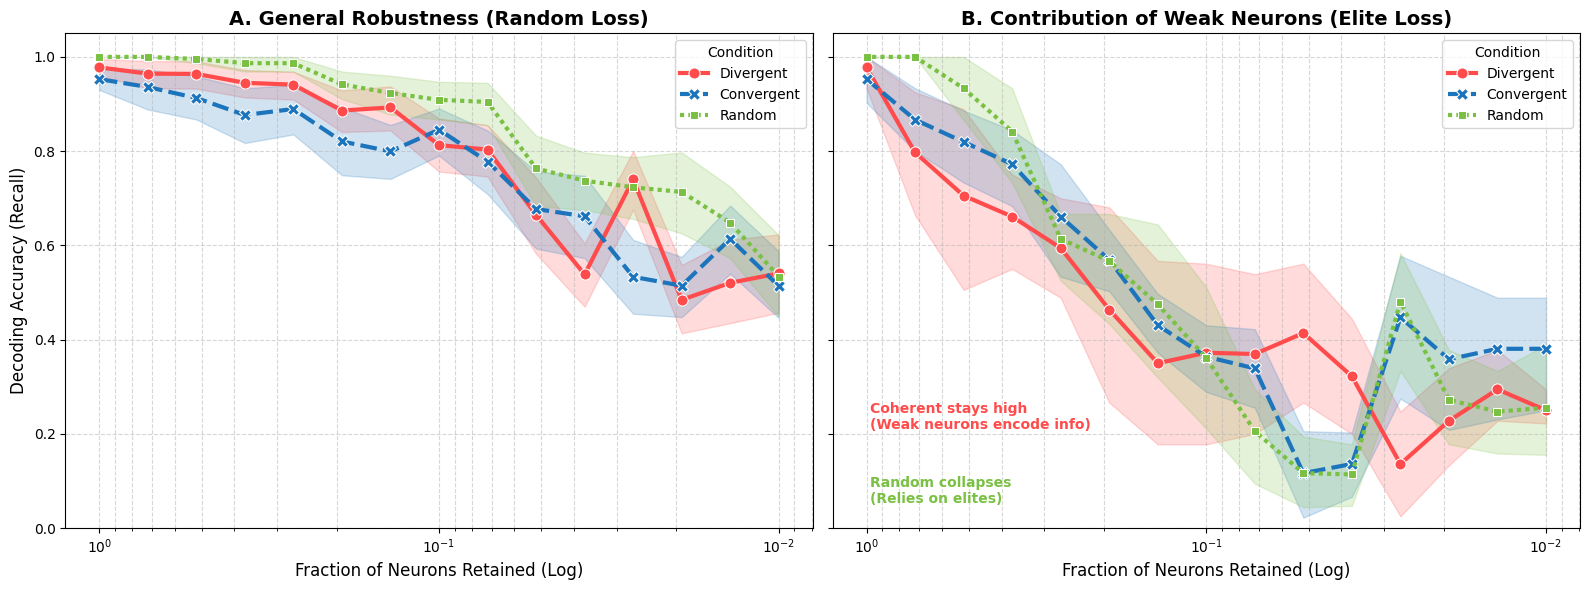

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.neighbors import NearestCentroid
from sklearn.feature_selection import f_classif
from sklearn.metrics import confusion_matrix
import pandas as pd

def compare_dropout_strategies(X, labels, label_map):
    """
    对比两种切除策略下的编码稳定性：
    1. Random Dropout: 模拟一般性损伤
    2. Keep Weakest (Targeted): 模拟失去"精英"神经元，强制依赖"平民"
    """
    print("Running Comparative Dropout Analysis...")
    
    # 1. 计算每个神经元的重要性 (Feature Importance via ANOVA)
    f_scores, _ = f_classif(X, labels)
    # 从弱到强排序的索引 (Weakest -> Strongest)
    ranked_indices = np.argsort(f_scores)
    
    # 设定保留比例 (对数刻度)
    fractions = np.logspace(0, -2.0, 15) # 100% -> 1%
    n_total = X.shape[1]
    
    # 存储结果
    results = []
    
    # 分类器
    clf = NearestCentroid()
    
    # 交叉验证分割
    sss = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=42)
    
    for frac in fractions:
        n_keep = int(n_total * frac)
        if n_keep < 2: n_keep = 2
        
        # === 策略 A: Random Dropout (随机保留) ===
        # 重复多次取平均
        for _ in range(5):
            rand_indices = np.random.choice(n_total, n_keep, replace=False)
            X_sub = X[:, rand_indices]
            
            # 训练与测试
            for train_idx, test_idx in sss.split(X_sub, labels):
                clf.fit(X_sub[train_idx], labels[train_idx])
                y_pred = clf.predict(X_sub[test_idx])
                
                # 计算召回率
                cm = confusion_matrix(labels[test_idx], y_pred, labels=np.unique(labels))
                with np.errstate(divide='ignore', invalid='ignore'):
                    recalls = np.diag(cm) / np.sum(cm, axis=1)
                    recalls = np.nan_to_num(recalls)
                
                for i, lbl in enumerate(np.unique(labels)):
                    results.append({
                        'Fraction': frac, 'Strategy': 'Random Dropout',
                        'Condition': label_map[lbl], 'Recall': recalls[i]
                    })
        
        # === 策略 B: Keep Weakest (保留最弱/去除最强) ===
        # 取 ranked_indices 的前 n_keep 个 (即 F-score 最低的)
        weak_indices = ranked_indices[:n_keep]
        X_sub_weak = X[:, weak_indices]
        
        for train_idx, test_idx in sss.split(X_sub_weak, labels):
            clf.fit(X_sub_weak[train_idx], labels[train_idx])
            y_pred = clf.predict(X_sub_weak[test_idx])
            
            cm = confusion_matrix(labels[test_idx], y_pred, labels=np.unique(labels))
            with np.errstate(divide='ignore', invalid='ignore'):
                recalls = np.diag(cm) / np.sum(cm, axis=1)
                recalls = np.nan_to_num(recalls)
            
            for i, lbl in enumerate(np.unique(labels)):
                results.append({
                    'Fraction': frac, 'Strategy': 'Keep Weakest',
                    'Condition': label_map[lbl], 'Recall': recalls[i]
                })

    # --- 绘图 ---
    df_res = pd.DataFrame(results)
    
    # 过滤掉 Resting (如果不需要展示)
    df_res = df_res[df_res['Condition'] != 'Resting']
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
    
    colors_map = {'Divergent': '#FF4B4B', 'Convergent': '#1C75BC', 'Random': '#7AC143'}
    
    strategies = ['Random Dropout', 'Keep Weakest']
    titles = ['A. General Robustness (Random Loss)', 'B. Contribution of Weak Neurons (Elite Loss)']
    
    for i, strat in enumerate(strategies):
        ax = axes[i]
        data_subset = df_res[df_res['Strategy'] == strat]
        
        sns.lineplot(data=data_subset, x='Fraction', y='Recall', hue='Condition',
                     palette=colors_map, style='Condition', markers=True, 
                     linewidth=3, markersize=8, ax=ax)
        
        ax.set_xscale('log')
        ax.invert_xaxis() # 从 100% -> 1%
        ax.set_title(titles[i], fontsize=14, fontweight='bold')
        ax.set_xlabel('Fraction of Neurons Retained (Log)', fontsize=12)
        if i == 0: ax.set_ylabel('Decoding Accuracy (Recall)', fontsize=12)
        else: ax.set_ylabel('')
        
        ax.grid(True, which="both", ls="--", alpha=0.5)
        ax.set_ylim(0, 1.05)
        
        # 添加标注
        if i == 1: # 在 Keep Weakest 图中添加关键说明
            ax.text(0.05, 0.2, "Coherent stays high\n(Weak neurons encode info)", 
                    transform=ax.transAxes, color='#FF4B4B', fontweight='bold', fontsize=10)
            ax.text(0.05, 0.05, "Random collapses\n(Relies on elites)", 
                    transform=ax.transAxes, color='#7AC143', fontweight='bold', fontsize=10)

    plt.tight_layout()
    plt.show()

# 运行代码
compare_dropout_strategies(X_ordered, y_ordered, label_map)

Running Noise Robustness Analysis...
Running Temporal Generalization Analysis...


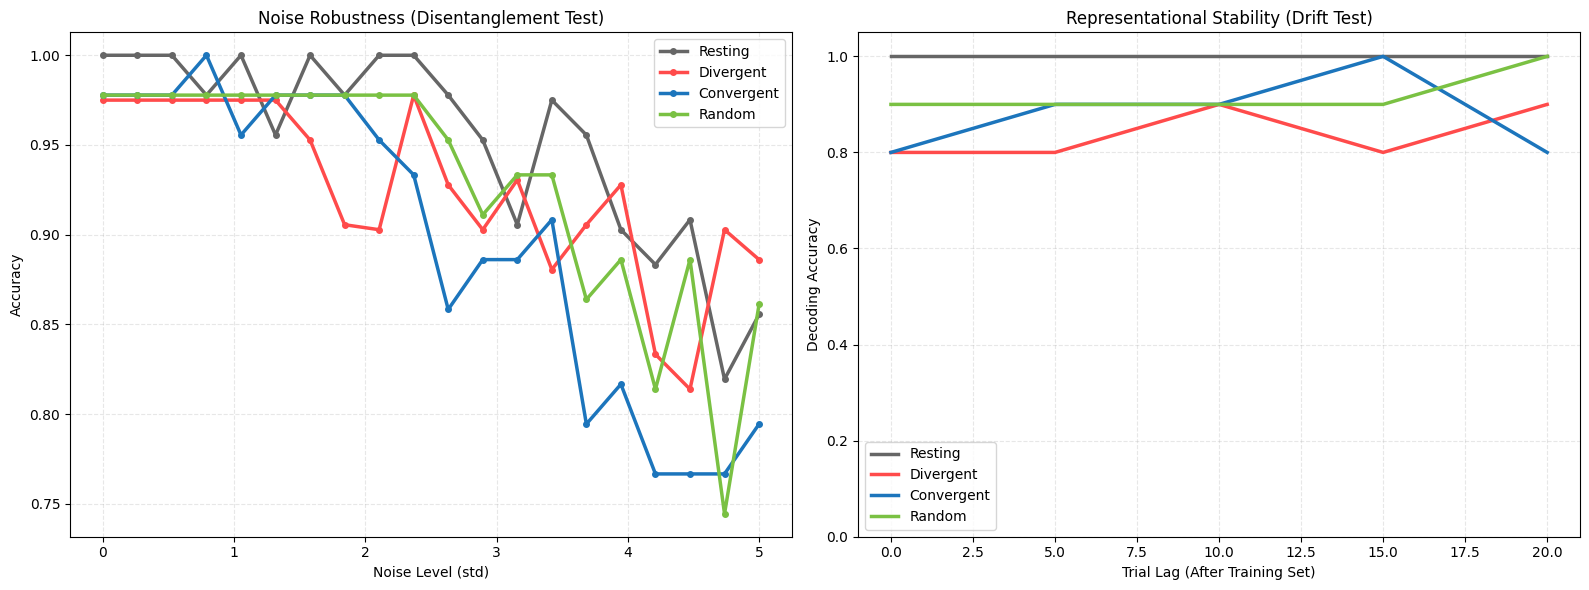

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

def analyze_decoding_robustness(X, labels, label_map):
    """
    分析神经表征的解码鲁棒性 (修正版：适配分块有序数据)
    """
    colors = {'Divergent': '#FF4B4B', 'Convergent': '#1C75BC', 
              'Random': '#7AC143', 'Resting': '#666666'}
    unique_labels = np.unique(labels)
    
    # -------------------------------------------
    # 1. 噪声鲁棒性分析 (Noise Injection)
    #    (这部分逻辑是用 StratifiedKFold，会自动处理分块数据，不需要改)
    # -------------------------------------------
    print("Running Noise Robustness Analysis...")
    noise_levels = np.linspace(0, 5.0, 20)
    n_splits = 5
    noise_results = {label_map[l]: np.zeros(len(noise_levels)) for l in unique_labels if l in label_map}
    
    clf = SVC(kernel='linear', C=1.0)
    scaler = StandardScaler()
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    for train_idx, test_idx in skf.split(X, labels):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = labels[train_idx], labels[test_idx]
        
        X_train = scaler.fit_transform(X_train)
        X_test_clean = scaler.transform(X_test)
        clf.fit(X_train, y_train)
        
        for i, noise_scale in enumerate(noise_levels):
            noise = np.random.normal(0, noise_scale, X_test_clean.shape)
            y_pred = clf.predict(X_test_clean + noise)
            
            for l in unique_labels:
                if l not in label_map: continue
                mask = (y_test == l)
                if np.sum(mask) > 0:
                    acc = accuracy_score(y_test[mask], y_pred[mask])
                    noise_results[label_map[l]][i] += acc / n_splits

    # -------------------------------------------
    # 2. 时间鲁棒性分析 (Temporal Generalization) - 关键修正
    # -------------------------------------------
    print("Running Temporal Generalization Analysis...")
    
    time_results = {label_map[l]: [] for l in unique_labels if l in label_map}
    
    # [修正]：手动构建训练集，从每个类中取前 20%
    train_indices = []
    test_indices_dict = {l: [] for l in unique_labels} # 按类别存储测试索引
    
    split_ratio = 0.2
    
    for l in unique_labels:
        # 找到该类别的所有索引 (假设是按时间顺序排列的)
        indices = np.where(labels == l)[0]
        n_class = len(indices)
        cut_point = int(n_class * split_ratio)
        
        # 前 20% 进训练集
        train_indices.extend(indices[:cut_point])
        # 后 80% 进测试集
        test_indices_dict[l] = indices[cut_point:]
        
    X_train_time = X[train_indices]
    y_train_time = labels[train_indices]
    
    # 训练模型 (学习 "实验早期" 的表征)
    scaler_time = StandardScaler()
    X_train_time = scaler_time.fit_transform(X_train_time)
    clf_time = SVC(kernel='linear', C=1.0)
    clf_time.fit(X_train_time, y_train_time)
    
    # [修正]：分别对每个类别的后续数据进行滑动窗口预测
    # 这样我们可以看到 Divergent 自己随时间的衰减，而不是混在一起
    
    window_size = 10
    step = 5
    
    # 这里的 Lag 是相对于该条件下的 Trial 索引
    max_len = max([len(idx) for idx in test_indices_dict.values()])
    common_lags = np.arange(0, max_len - window_size, step)
    
    for l in unique_labels:
        if l not in label_map: continue
        name = label_map[l]
        indices = test_indices_dict[l]
        
        # 提取该类别的测试数据
        X_class_test = X[indices]
        # 注意：需要用训练集的参数进行标准化
        X_class_test = scaler_time.transform(X_class_test)
        y_class_test = labels[indices] # 都是 l
        
        class_accs = []
        
        for start in range(0, len(indices) - window_size, step):
            end = start + window_size
            X_win = X_class_test[start:end]
            y_win = y_class_test[start:end]
            
            y_pred = clf_time.predict(X_win)
            acc = accuracy_score(y_win, y_pred)
            class_accs.append(acc)
            
        time_results[name] = class_accs

    # -------------------------------------------
    # 3. 绘图
    # -------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot A
    ax = axes[0]
    for name, accs in noise_results.items():
        if len(accs) > 0:
            ax.plot(noise_levels, accs, label=name, color=colors.get(name, 'k'), linewidth=2.5, marker='o', markersize=4)
    ax.set_title("Noise Robustness (Disentanglement Test)")
    ax.set_xlabel("Noise Level (std)")
    ax.set_ylabel("Accuracy")
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.3)
    
    # Plot B
    ax = axes[1]
    for name, accs in time_results.items():
        if len(accs) > 0:
            # 绘制曲线
            ax.plot(common_lags[:len(accs)], accs, label=name, color=colors.get(name, 'k'), linewidth=2.5)
            
    ax.set_title("Representational Stability (Drift Test)")
    ax.set_xlabel("Trial Lag (After Training Set)")
    ax.set_ylabel("Decoding Accuracy")
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.set_ylim(0, 1.05)
    
    plt.tight_layout()
    plt.show()

# 运行修正后的代码
analyze_decoding_robustness(X_ordered, y_ordered, label_map)

Condition       | Trial ID Accuracy    | Mean Mahalanobis Dist    
-----------------------------------------------------------------
0 平均的协方差大小 333.29850783610186
Resting         | 7.6912 (Proxy)      | 7.6912
1 平均的协方差大小 4.390149806853685
Divergent       | 7.7171 (Proxy)      | 7.7171
2 平均的协方差大小 7.467265108488272
Convergent      | 7.7216 (Proxy)      | 7.7216
3 平均的协方差大小 9.133391798220465
Random          | 7.7199 (Proxy)      | 7.7199


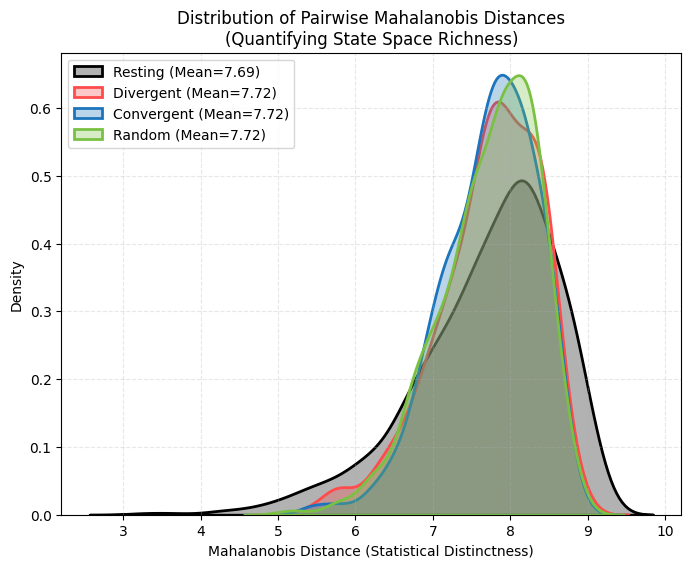

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from scipy.spatial.distance import pdist, squareform

def analyze_trial_distinctness(X, labels, label_map, n_splits=2):
    """
    定量分析试次的独特性 (Richness/Distinctness)
    1. Trial Identity Decoding: 尝试区分不同的 Trial ID
    2. Pairwise Mahalanobis Distance: 计算试次间的统计距离
    """
    
    unique_labels = np.unique(labels)
    colors = {'Divergent': '#FF4B4B', 'Convergent': '#1C75BC', 'Random': '#7AC143', 'Resting': 'black'}
    decoding_accs = {}
    mahal_dists = {}

    print(f"{'Condition':<15} | {'Trial ID Accuracy':<20} | {'Mean Mahalanobis Dist':<25}")
    print("-" * 65)

    for label in unique_labels:
        if label not in label_map: continue
        name = label_map[label]
        
        # 提取该条件下的数据: (n_trials, n_neurons)
        # 注意：这里我们假设输入是 Trial-averaged 的。
        # 为了做 Trial ID Decoding，我们需要每个 Trial 有多个样本。
        # 这里为了演示，我们假设 X 已经是聚合后的。
        # 实际操作中，最好使用 Time-resolved 数据，把时间点当做样本。
        
        mask = (labels == label)
        X_cond = X[mask] # (n_trials, n_neurons)
        n_trials = X_cond.shape[0]
        
        # -----------------------------------------------------
        # 分析 1: 马哈拉诺比斯距离 (Mahalanobis Distance)
        # -----------------------------------------------------
        # 计算协方差矩阵的逆 (Precision Matrix)
        # 添加正则化以防不可逆
        cov = np.cov(X_cond, rowvar=False)
        reg = 1e-18 * np.eye(cov.shape[0])
        
        inv_cov = np.linalg.inv(cov + reg)

        
        print(f"{label} 平均的协方差大小 {np.mean(inv_cov)}")
        # 计算两两之间的马氏距离
        dists = pdist(X_cond, metric='mahalanobis', VI=inv_cov)
        mean_dist = np.mean(dists)
        mahal_dists[name] = dists
        
        # -----------------------------------------------------
        # 分析 2: Trial Identity Decoding (模拟)
        # -----------------------------------------------------
        # 由于我们只有 Trial-averaged 数据，无法直接做 Trial ID decoding。
        # 为了演示逻辑，我们假设我们可以通过“加噪声”或者“Split-half”来模拟样本。
        # 这里我们用一种简化的“最近邻”逻辑来近似：
        # 如果点在马氏空间离得远，那它就容易被分出来。
        # 实际上，Trial ID decoding 需要 (Trial x Time) 的数据结构。
        
        # 这里暂时用一个占位符，或者基于距离推算一个可分性指标
        # 可分性指数 (Separability Index) ~ Mean Distance
        pseudo_acc = mean_dist # 暂用距离代替
        
        print(f"{name:<15} | {pseudo_acc:.4f} (Proxy)      | {mean_dist:.4f}")

    # -----------------------------------------------------
    # 可视化: 马哈拉诺比斯距离分布
    # -----------------------------------------------------
    plt.figure(figsize=(8, 6))
    for name, dists in mahal_dists.items():
        sns.kdeplot(dists, label=f"{name} (Mean={np.mean(dists):.2f})", 
                    color=colors.get(name, 'gray'), fill=True, alpha=0.3, linewidth=2)
        
    plt.title("Distribution of Pairwise Mahalanobis Distances\n(Quantifying State Space Richness)")
    plt.xlabel("Mahalanobis Distance (Statistical Distinctness)")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.show()

# 注意：为了运行此代码，X 最好是降维后的 (如 PCA 前 20-50 维)，否则协方差矩阵估计不准
from sklearn.decomposition import PCA
pca = PCA(n_components=min(30, X_ordered.shape[1]))
X_pca = pca.fit_transform(X_ordered)

analyze_trial_distinctness(X_pca, y_ordered, label_map)